In [1]:
import os
import sys
import scipy
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import scipy.io as sio
import scanpy.external as sce
import matplotlib.pyplot as plt
import re
import anndata as ad
import statistics
import torch
import scvi
import tempfile
import sklearn
import mudata as md
md.set_options(pull_on_update=False)
import muon
from datetime import datetime
from scib_metrics.benchmark import Benchmarker
from scvi.model.utils import mde
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from multiprocessing import Pool
print("Last run with scvi-tools version:", scvi.__version__)
scvi.settings.seed = 0
sc._settings.ScanpyConfig.n_jobs=24
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='png')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/home/liyanguo/anaconda3/envs/R/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Impo

Last run with scvi-tools version: 1.2.0


In [2]:
sc.logging.print_header()

Package,Version
scipy,1.15.2
numpy,1.26.4
pandas,2.2.3
scanpy,1.11.0
seaborn,0.13.2
matplotlib,3.9.2
anndata,0.11.3
torch,2.4.1 (2.4.1+cu121)
scvi-tools,1.2.0
scikit-learn,1.5.2


In [3]:
obj_path = '/home/liyanguo/MyImmuCell/04_Ref_Atlas_scVI/'
sc.settings.figdir = obj_path

In [4]:
#dataset = sys.argv[1]
dataset = "Ref_Atlas"

In [5]:
adata = sc.read_h5ad(f"{obj_path}{dataset}_scRNA_preprocess_scVI.h5ad")

# 0. Load scVI model if needed

# 1. Load latent representation

In [6]:
adata.obsm["X_scVI"]=np.load(f"{obj_path}{dataset}_X_scVI.npy")

In [7]:
# sc.pp.neighbors take about 60 minutes for 2900M cells
print(f"Do sc.pp.neighbors with AnnoyTransformer,{datetime.now()}")
sc.pp.neighbors(adata, transformer=AnnoyTransformer(20), use_rep='X_scVI')

Do sc.pp.neighbors with AnnoyTransformer,2025-04-18 17:57:21.299435


In [8]:
print(f"Run UMAP,{datetime.now()}")
sc.tl.umap(adata, min_dist=0.5)

Run UMAP,2025-04-18 17:58:24.614798


In [9]:
print(f"Do sc.tl.leiden with resolution=3,{datetime.now()}")
sc.tl.leiden(adata, key_added='L1_leiden_scVI_3', resolution=3,
             use_weights=True,directed=False,flavor="igraph")

Do sc.tl.leiden with resolution=3,2025-04-18 18:19:52.717704


In [10]:
print(f"Do sc.tl.leiden with resolution=4,{datetime.now()}")
sc.tl.leiden(adata, key_added='L1_leiden_scVI_4', resolution=4,
             use_weights=True,directed=False,flavor="igraph")

Do sc.tl.leiden with resolution=4,2025-04-18 18:20:48.208536


In [11]:
print(f"Do sc.tl.leiden with resolution=5,{datetime.now()}")
sc.tl.leiden(adata, key_added='L1_leiden_scVI_5', resolution=5,
             use_weights=True,directed=False,flavor="igraph")

Do sc.tl.leiden with resolution=5,2025-04-18 18:21:44.902582


# 2. Plot

Plot umap,2025-04-18 18:22:38.149156


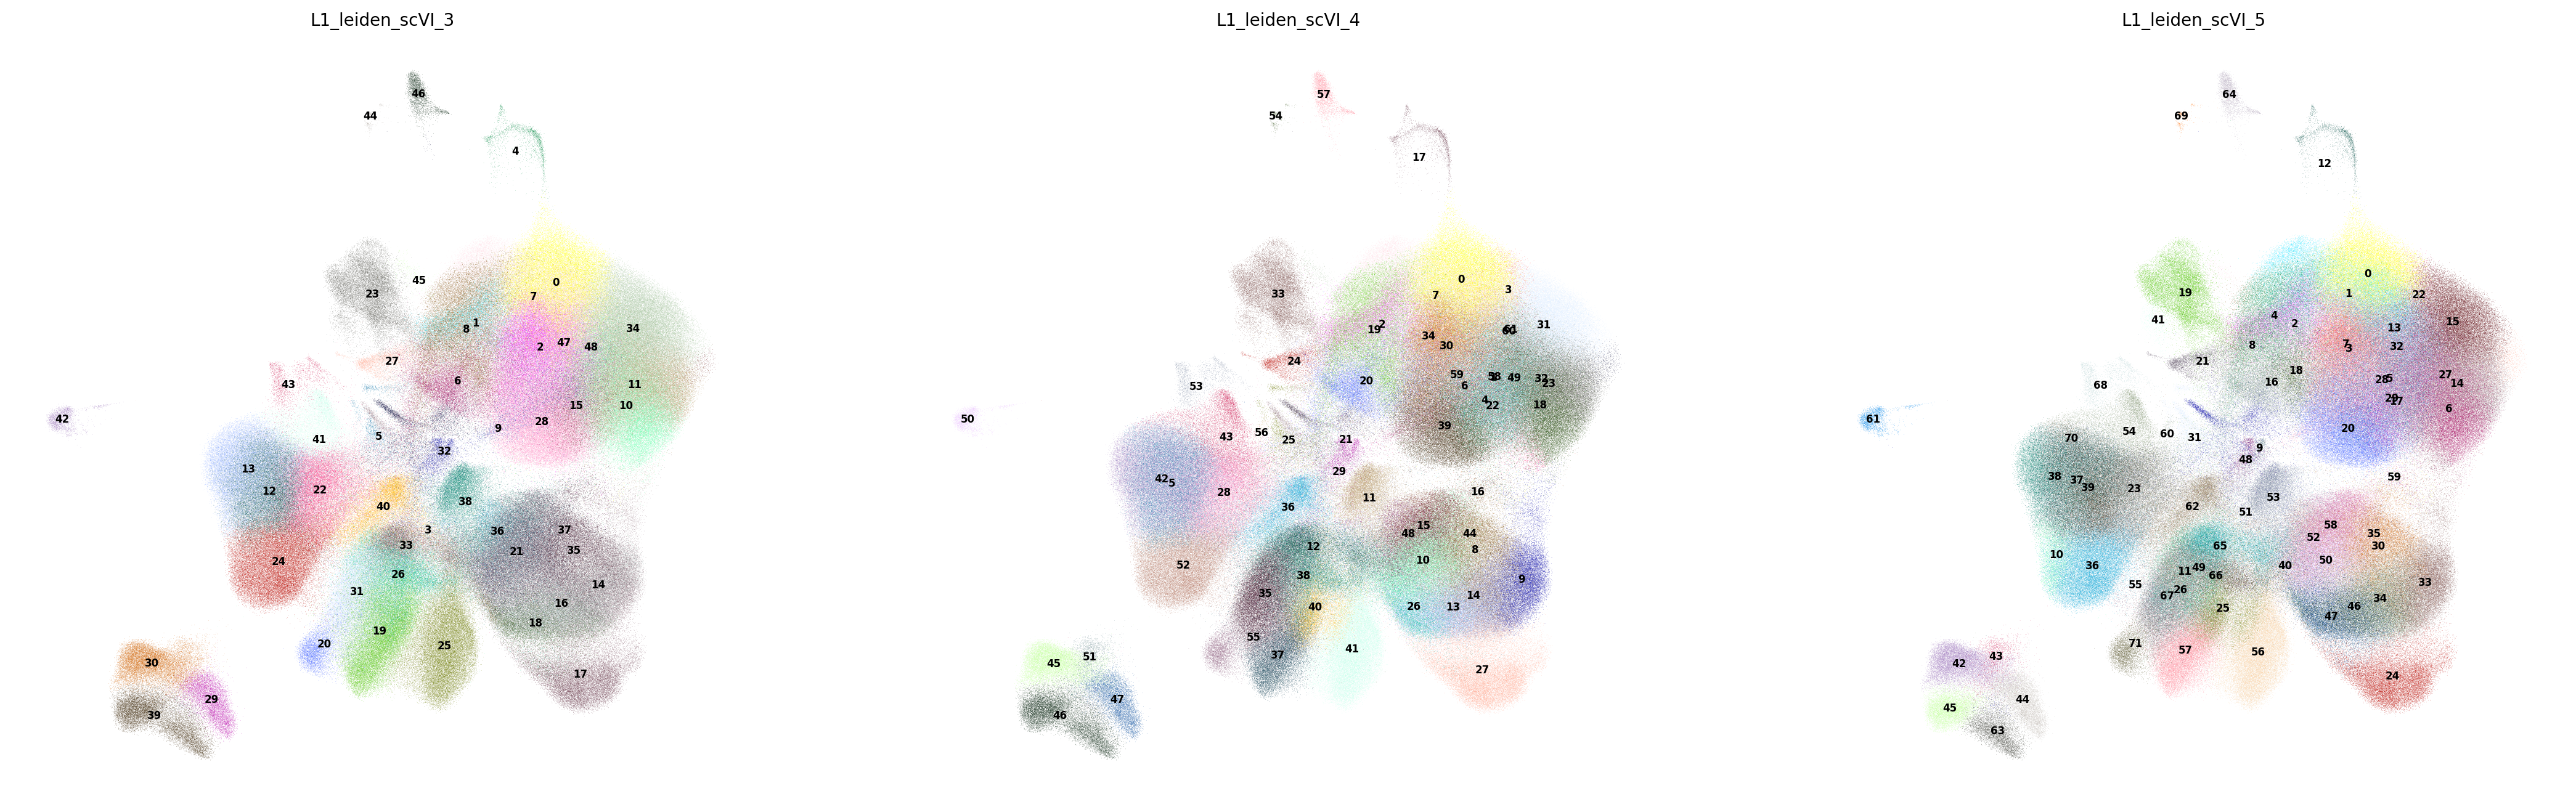

In [12]:
print(f"Plot umap,{datetime.now()}")
sc.pl.umap(
    adata,
    color=['L1_leiden_scVI_3','L1_leiden_scVI_4','L1_leiden_scVI_5'],
    legend_fontsize=6,legend_loc='on data',ncols=3,frameon=False,
    save=f'_{dataset}_scVI_L1_annoy_leiden'
)

# 3. Get all gene count data

In [13]:
adata_raw = sc.read_h5ad(f'/home/liyanguo/MyImmuCell/02_Read_QC/scRNA_{dataset}.h5ad')

In [14]:
adata_raw = adata_raw[adata.obs_names,:].copy()

In [15]:
adata.raw = adata_raw
adata = adata.raw.to_adata()

In [16]:
adata.write(f"{obj_path}{dataset}_umap_leiden_scVI.h5ad",compression="gzip")

In [17]:
adata.X.max()

4753.0

In [18]:
adata

AnnData object with n_obs × n_vars = 888260 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'predicted.celltype.l1', 'predicted.celltype.l2', 'predicted.celltype.l3', 'scDblFinder.class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'High_quality', 'Batch', 'L1_leiden_scVI_3', 'L1_leiden_scVI_4', 'L1_leiden_scVI_5'
    uns: 'hvg', 'log1p', 'neighbors', 'umap', 'L1_leiden_scVI_3', 'L1_leiden_scVI_4', 'L1_leiden_scVI_5', 'L1_leiden_scVI_3_colors', 'L1_leiden_scVI_4_colors', 'L1_leiden_scVI_5_colors'
 

# 4. Plot marker genes

In [19]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [20]:
marker_dict1={
    'Immune cell': ['PTPRC'],

    'Lineage':['CD7','CD3E',
               'IL7R',
               'SPON2','KLRF1',
               'CD79A','MS4A1',
               'CD14','FCGR3A',
               'CSF3R','FCGR3B'
              ],
    
    'HSPC':['CD34','SPINK2','CYTL1','PROM1','SMIM24','EGFL7',
            'SOX4','KIT', 'DNTT','ETV6','MCL1','STAT5A','CD48'],
    'Basophil':['HDC','GATA2', 'FCER1A', 'IL3RA','ENPP3','MS4A2','IL4'],
    'Eosinophil':['ALOX15','SIGLEC10','SIGLEC8','LMO4','EPX','ITGA1','CCR3',],
    'Mast cell':['FCER1A','MS4A2','KIT'],

    'CEACAM8- Neutrophil':['FCGR3B','CSF3R','MME','G0S2','MNDA',],
    'CEACAM8+ Neutrophil':['CEACAM8','LTF','BPI','MPO','ELANE'],
    
    'Classical monocytes' :['CD14','LYZ','VCAN','FCN1',],
    'Non-classical monocytes' :['FCGR3A','CDKN1C','TCF7L2','CSF1R',],
    'DC':['ENHO','CD1C','HLA-DQA1','FCER1A','CLEC10A','CLEC9A','FLT3'],
    'pDC':['CLEC4C','IL3RA'],
    
    'T naive': ['CD3D','CD3G','LEF1','IL7R','CCR7', 'TCF7','SELL','BACH2'],
    'CD4+ T': ['CD4','MAL','RCAN3','IL6ST','TRAT1','CAMK4'],
    'TRAV1-2- CD8+ T': ['CD8A', 'CD8B','LINC02446','CCL5','GZMH','GZMK','ZNF683','THEMIS'],
    'γδ T':['TRDV2','TRGV9','TRDC','KLRG1','TRGC1','TRGC2','CCL5','CST7',],
    'MAIT':['SLC4A10','KLRB1','TRAV1-2','RORA','CXCR6'],
    'Treg':['FOXP3','CTLA4','IL2RA','TIGIT','RTKN2','STAM'],

    'NK': ['KLRD1','GNLY','PRF1','GZMB','CD244','CD247',
           'IL2RB','XCL1','XCL2'],
    'CD56dim':['FCGR3A','SPON2',],#CD16+
    'CD56bright':['IL7R','GZMK','NCAM1','GATA3'],#CD16-/low
    'Adaptive NK':['KLRC2','B3GAT1',],

    'Lymphocyte relate':['RUNX1','RUNX2','KLRF1','KLRC1',#KLRC1=NKG2AA抑制   NKp80=KLRF1
                         'KLRD1','KLRG1','EOMES',
                        'NCR2','NCR3','SYNE1'],#KLRD1=CD94抑制 KLRG1抑制

    'ILC': ['IL7R','LTB','RGS1','TNFSF10','PLCG2','RUNX1','TOX','FLT3'],#lin-
    'pILC':['NFIL3',],
    'ILC1':['IL2RB','TBX21','NCR1',],#CD56-
    'ILC2':['GATA3','IL2RA','PTGDR2','KLRG1','ZBTB16','RORA','MAF'],#lin- CD4-
    'ILC3-NCR+':['AHR','KIT','RORC','NCR1','NCR2','RUNX2',],#mature ILC #lin- CD56+ CD4-
    'LTi':['CCR7','KIT','ITGA4',],#mature ILC #lin- CD56-
    'ILCreg':['SOX4',],#KLRG1-
    
    'NKT':['TRAV24','TRBV28','CLDND1'], 
    'DN T':['FXYD2','NUCB2','MYB',],
    'T Develop':['SPI1','ZBTB7B','RUNX3'],
    'T activation': ['CD69', 'CD38'],

    'B naive': ['CD79A','TCL1A',],
    'Transitional B': ['EBF1','BACH2','PAX5', 'MSI2',],
    'Atypical memory B': ['TBX21','ITGAX','FCRL5','SIGLEC6','SOX5'],
    'Plasma':['JCHAIN','IGHA1','TNFRSF17','MZB1','CD38','XBP1', 'PRDM1'],
    'CD5+ B':['IGHV3-7','LEF1','CTLA4','CD5'],

    'Platelet':['PF4','PPBP','GP9','CAVIN2'],
    'RBC':['HBB','HBA2','BLVRB'],
    'Proliferative signal':['MKI67','TOP2A','STMN1'],
    'Other':['ITGAM','ANK3','PRKCA','BCL6','TGFB1','CXCR4','GATA1','ATXN1','SELPLG',
             'ITGA6','CSF1','CSF1R','CSF2','ETS1','CD44','IRF4','STAT3','BATF','TGFBR1','TGFBR2']
}
#Protein :       CD114,  CD116,  CD123, CD124, CD125,  CD126, CD203c,  KLRB1,  CD25,   CD29,   CD73,  CD127,  CD119,  CRTH2,  PLZF, CD62L, TdT, CD57,     ThpOK,   PU.1, CRTH2
#Gene Symbol :	CSF3R,   CSF2RA, IL3RA, IL4R,  IL5RA,  IL6R, ENPP3,   CD161,  IL2RA,  ITGB1,  NT5E,  IL7R,  IFNGR1,  PTGDR2, ZBTB16, SELL, DNTT, B3GAT1, ZBTB7B,   SPI1, PTGDR2

#Protein :    CD42a, CD42b, 
#Gene Symbol :GP9, GP1BA

#TCR : Vα7.2
#Gene : TRAV1-2

#GCSF=CSF3, for neutrophils
#GM-CSF=CSF2, granulocyte-macrophage colony-stimulating factor
#M-CSF=CSF1, macrophage colony-stimulating factor

In [21]:
for group in ['L1_leiden_scVI_3','L1_leiden_scVI_4','L1_leiden_scVI_5']:
    sc.pl.dotplot(
        adata,
        groupby=group,
        save=f"{dataset}_{group}_marker",
        var_names=marker_dict1,
        standard_scale="var",
        dot_min=0.1,
        show=False
    )

# 5. Plot marker genes from 500W reference

In [22]:
marker_dict2={
    'B': ['MS4A1','CD79A','BANK1','CD22','FCRL1',],
    'Plasma|Plasmablast':['TNFRSF17','JCHAIN','IGHA2','MZB1'],
    
    'CD4+ T':['TCF7','MAL','IL7R','RCAN3','DGKA',],
    'CD8+ T':['CD8A','CD8B','LINC02446','CCL5','THEMIS'],
    'MAIT':['SLC4A10','TRAV1-2','KLRB1',],
    'Platelet':['TUBB1','CAVIN2','PF4',],
    'NKT':['TRAV24','TRBV28','CLDND1','DZIP3'],
    'NK': ['KLRF1', 'SPON2','GNLY', 'GZMB','PRF1'],
    'non-NK ILC': ['FSTL4', 'HPGDS','PKIB', 'PTGDR2','SCART1'],
    'γδ T':['TRDV2','TRGC1','TRGC2','TRGV9','CCL5','KLRC1'],
    
    'HPSC':['CD34','NPR3','SMIM24','SPINK2', 'CRHBP'],
    'Dendritic':['ENHO','CLEC10A','CD1C','FCER1A','FLT3'],
    'Classical monocyte':['FCN1','VCAN','LRP1','CD14','MS4A6A',],
    'Non-classical monocyte':['CDKN1C','CSF1R','CKB','NEURL1','LYPD2'],
    'CEACAM8+ Neutrophil':['CEACAM8','LCN2','BPI','LTF','CRISP3'],
    'CEACAM8- Neutrophil':['CSF3R','NAMPT','FCGR3B','IFITM2','SLC25A37'],
    'Eosinophil':['EPX', 'SIGLEC8', 'IL5RA'],
    'Basophil':['HDC','GATA2','MS4A2','AKAP12','CLC'],
    'pDC':['SERPINF1','PTPRS','LILRA4','TNFRSF21','PLD4',],
    
    'Proliferative signal':['MKI67','TOP2A','STMN1'],
}

In [23]:
for group in ['L1_leiden_scVI_3','L1_leiden_scVI_4','L1_leiden_scVI_5']:
    sc.pl.dotplot(
        adata,
        groupby=group,
        save=f"{dataset}_{group}_ref_markers",
        var_names=marker_dict2,
        standard_scale="var",
        dot_min=0.1,
        show=False
    )